In [ ]:
import os 
current_path = os.getcwd()
os.chdir(current_path+'/..')
from data.tools import create_armcoda_signal, create_armcoda_signal_from_idxes, create_armcoda_signal_from_idxes_dims_positions, mask_to_dict, dict_to_mask
from multivariate_tsmd.utils import plot_signal_and_motifs, plot_signal_and_submotifs, plot_signal_and_motifs_by_dimension
from multivariate_tsmd.competitors.mMotifs import mMotifs
from src.sDimMotifs import sDimMotifs
from tsmd.competitors.matrixprofile import MatrixProfile
from multivariate_tsmd.competitors.univariate_after_PCA import UnivariateAfterPCA
os.chdir(current_path)
import random

✅ Figure SVG sauvegardée : toy_example.svg


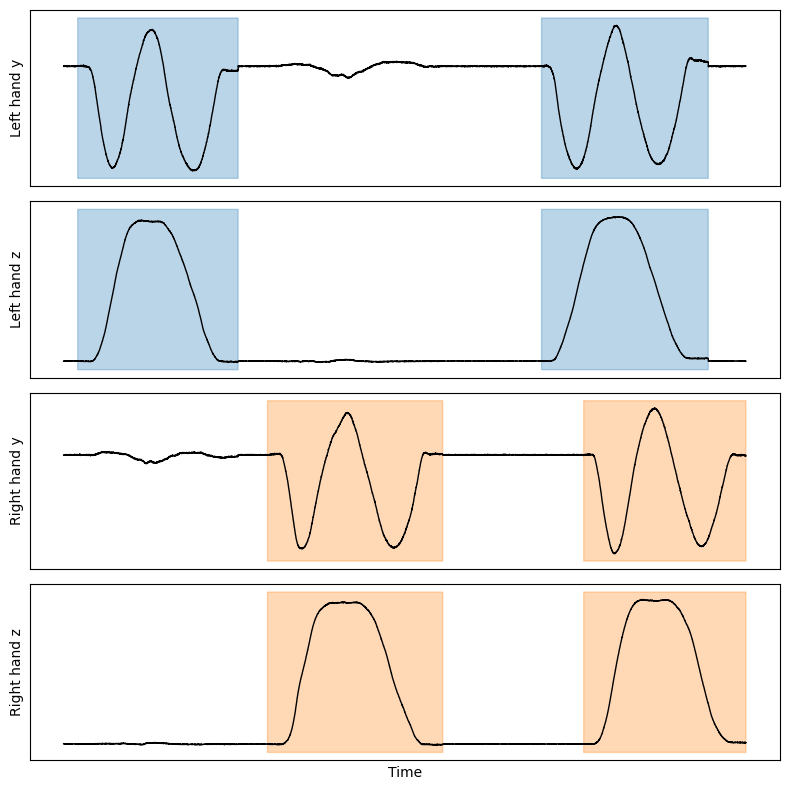

In [ ]:
idxes_list=[]
  
idxes_list.append([0,11,0])
idxes_list.append([0,12,0])
idxes_list.append([0,11,1])
idxes_list.append([0,12,1])


hand_sensors = [20,29]
dimension_mask = []
left_hand_dims = [20*3+1, 20*3+2]
right_hand_dims = [29*3+1, 29*3+2]

dimension_mask.extend(left_hand_dims)
dimension_mask.extend(right_hand_dims)

active_dimensions = [dimension_mask]*2 + [left_hand_dims, right_hand_dims]
positions = [100, 1450, 3400, 3700] 
signal,mask,idxes_list=create_armcoda_signal_from_idxes_dims_positions(idxes_list, active_dimensions, positions=positions, save=False, id='left_vs_right')
signal = signal[:, dimension_mask]

dimensions=[]
dimensions.append([i for i in range(signal.shape[1]//2)])
dimensions.append([i for i in range(signal.shape[1]//2, signal.shape[1])])

dimension_names=['Left hand y', 'Left hand z','Right hand y', 'Right hand z']
motifs_names=['Left hand sagittal plane elevation', 'Right hand sagittal plane elevation']

plot_signal_and_submotifs(signal,mask,dimensions,dimension_names, motifs_names, n_cols=1,col_width=8, show_axes=False, save_svg=True, svg_name="toy_example.svg")

✅ Figure SVG sauvegardée : mMotifs_result.svg


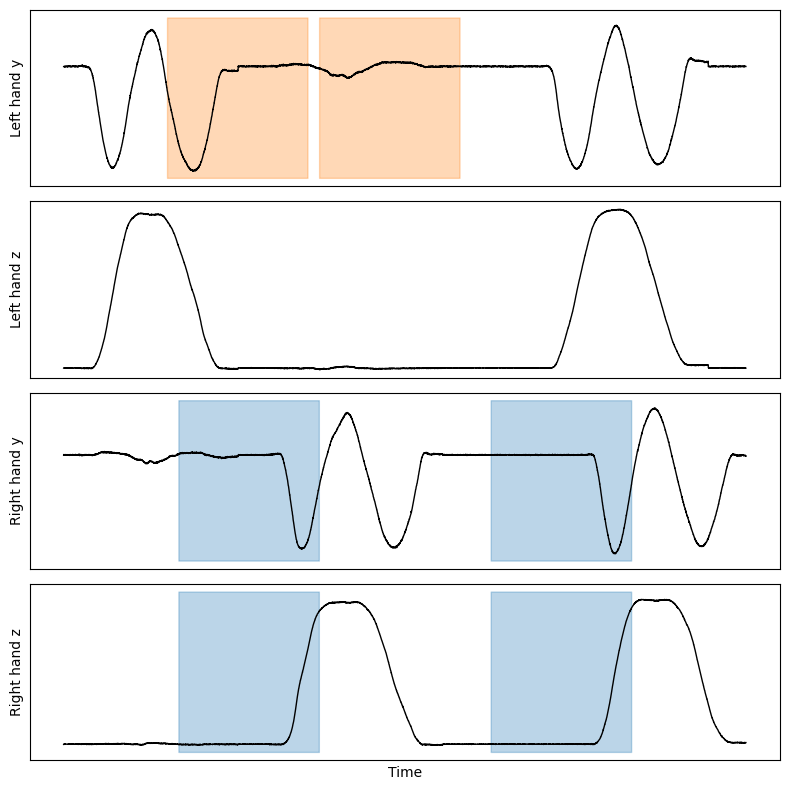

In [33]:
mmotifs= mMotifs(wlen=1000,n_patterns=2, excl_zone_denom=1)
mmotifs.fit(signal)
plot_signal_and_submotifs(signal,mmotifs.prediction_mask_,mmotifs.prediction_dimension_, dimension_names, n_cols=1,col_width=8, show_axes=False,save_svg=True, svg_name="mMotifs_result.svg")

✅ Figure SVG sauvegardée : mSubDimMotifs.svg


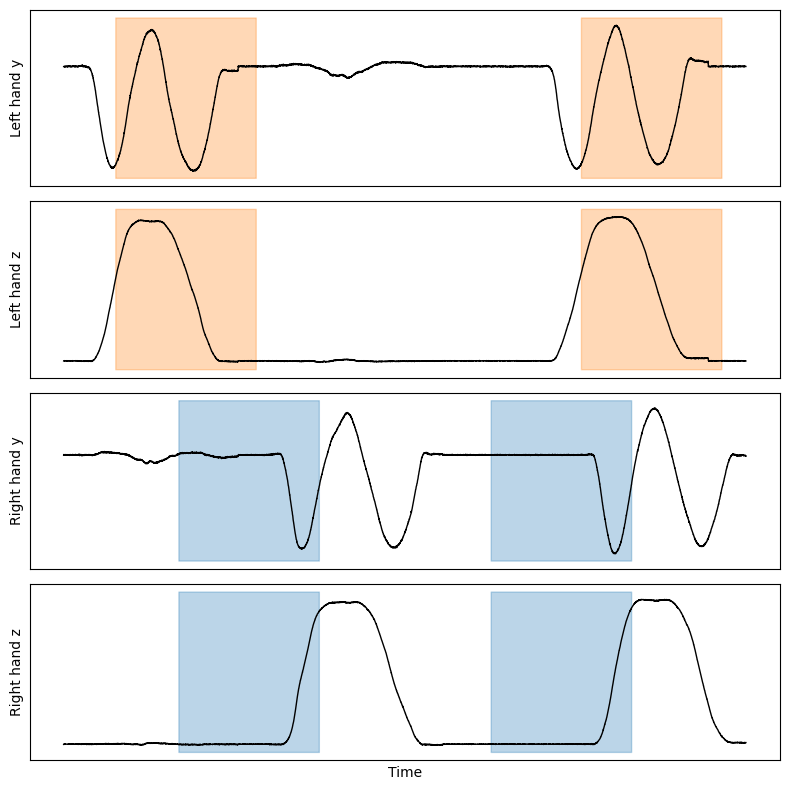

In [ ]:
mstamp= sDimMotifs(wlen=1000,n_patterns=2, radius_ratio=3)
mstamp.fit(signal)
plot_signal_and_submotifs(signal,mstamp.prediction_mask_,mstamp.prediction_dimension_,dimension_names,n_cols=1,col_width=8, show_axes=False,save_svg=True, svg_name="mSubDimMotifs.svg")

✅ Figure SVG sauvegardée : MP.svg


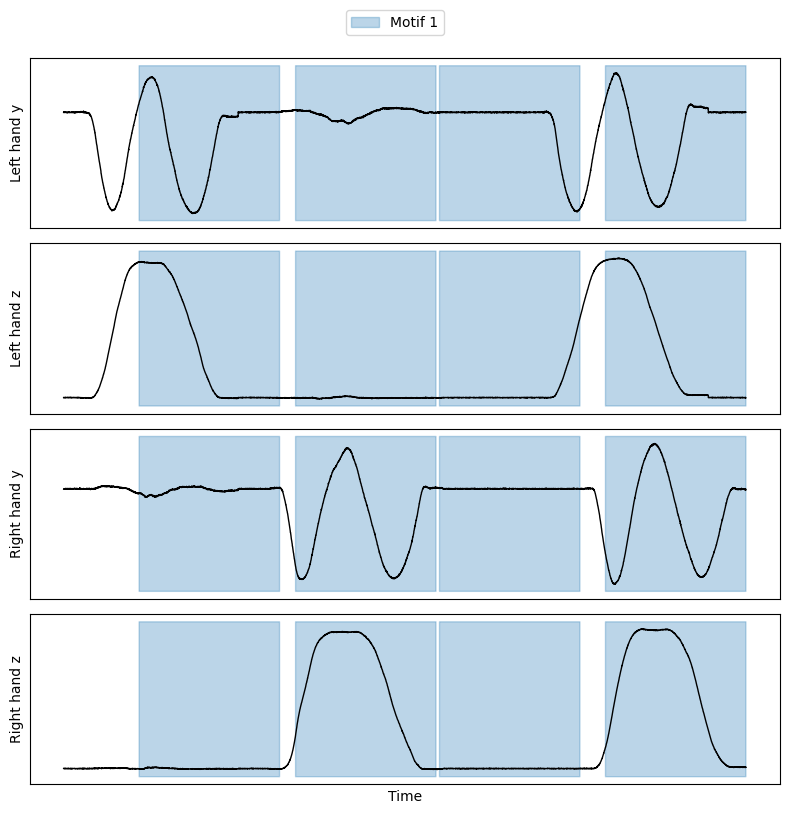

In [5]:
mp= MatrixProfile(wlen=1000,n_patterns=2, radius_ratio=3, distance_name='MVUnitEuclidean')
mp.fit(signal)
plot_signal_and_motifs(signal,mp.prediction_mask_, dimension_names=dimension_names,show_axes=False,col_width=8,save_svg=True, svg_name="MP.svg")

✅ Figure SVG sauvegardée : upca.svg


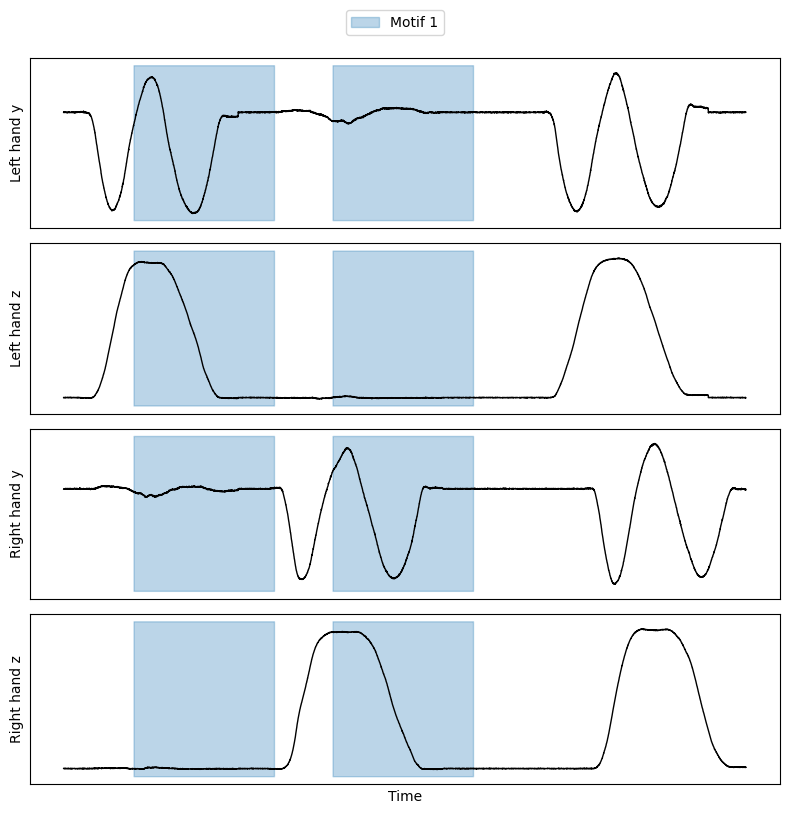

In [6]:
upca= UnivariateAfterPCA(univariate_method=MatrixProfile, method_params={'wlen':1000, 'n_patterns':1, 'radius_ratio':3, 'distance_name':'UnitEuclidean'})
upca.fit(signal)
plot_signal_and_motifs(signal,upca.prediction_mask_, dimension_names=dimension_names,show_axes=False,col_width=8,save_svg=True, svg_name="upca.svg")